# 🎨 Seaborn Part 2 — Themes, Styles, Contexts & Colour Palettes

**Topic:** 08.04 · **Level:** 🟠 Intermediate · **Type:** THEORY + CODE

## Making figures consistent and beautiful

This companion notebook to the categorical-plots session is about the **look** of your Seaborn figures. Every plot in Sessions 25 and 26 was shaped by a small set of global settings you can control — and if you master them, your charts stop looking like defaults and start looking like a designed dashboard.

Three knobs control the overall appearance:

- **Theme / style** — `sns.set_theme()` restores Seaborn's defaults; `sns.set_style('darkgrid')`, `'whitegrid'`, `'white'`, `'dark'` and `'ticks'` choose how the *background* and *grid lines* render. Whitegrid is the workhorse for data analysis (clean background + visible grid); `'ticks'` is the choice for print-style minimal charts.
- **Context** — `sns.set_context('paper' | 'notebook' | 'talk' | 'poster')` scales font sizes, line widths and marker sizes together, so a figure prepared on screen still reads correctly when blown up on a slide (`'talk'`) or compressed into a paper (`'paper'`).
- **Palette** — `sns.color_palette()` returns a list of colours, `sns.set_palette()` makes it the default for every following plot, and named palettes (`'deep'`, `'muted'`, `'pastel'`, `'bright'`, `'dark'`, `'colorblind'`, plus sequential like `'viridis'`) guarantee accessible, harmonious colours that clip well.

Settings applied through `set_*` functions are **global** — once called they affect every plot in the notebook until changed again. That is extremely convenient for keeping a set of plots consistent, and it is exactly how a polished report gets its unified style. Because Jupyter keeps state cell by cell, the notebook's `set_theme()` call near the top silently explains why every later chart shares the same background, fonts and colour ramp. Work through the cells, run each palette side by side, and end by choosing a style you can defend for your own projects.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt


tips = sns.load_dataset('tips')

# Themeing

* `set_theme`

> Set aspects of the visual theme for all matplotlib and seaborn plots.

* `axes_style`

> Get the parameters that control the general style of the plots.

* `set_style`

> Set the parameters that control the general style of the plots.

* `plotting_context`

> Get the parameters that control the scaling of plot elements.

* `set_context`

> Set the parameters that control the scaling of plot elements.

* `set_color_codes`

> Change how matplotlib color shorthands are interpreted.

* `reset_defaults`

> Restore all RC params to default settings.

* `reset_orig`

> Restore all RC params to original settings (respects custom rc).


## `set_theme` function : 
> This function is used to set the theme of your plots, it can take a variety of inputs such as 'darkgrid', 'whitegrid', 'dark', 'white' or 'ticks'.

Example: 

In [2]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: >

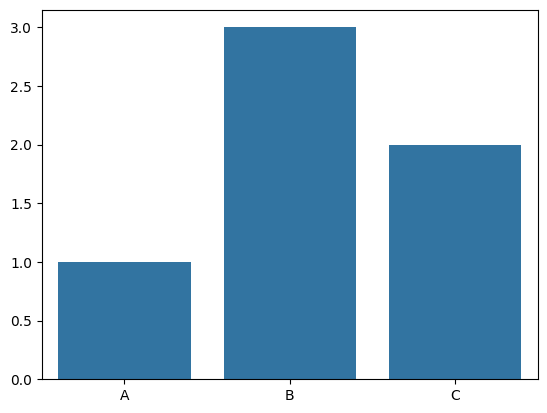

In [3]:
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

## 🔬 Deep Dive : set_theme — global plot style

```python
sns.set_theme(style='whitegrid')      # high-level all-in-one theming
```

- set_theme — global defaults: style + palette + context + font
- style values: 'white', 'dark', 'whitegrid', 'darkgrid', 'ticks'
- grid → readability; white ⇒ clean print
- Applies to all subsequent seaborn/matplotlib plots
- Runs once at notebook start for consistency
- `.set()` — persistent | axes_style(context manager) — temporary
- Example bars show instantly visual difference
- matplotlib affects too; default keys in seaborn style dict
- choose aesthetic — background choice determines tint
- call early — later plots consistent

<Axes: >

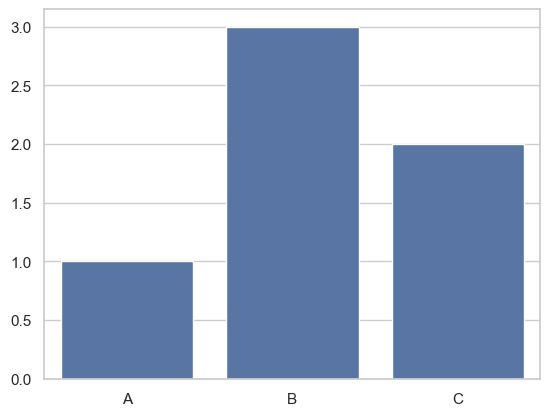

In [4]:
# Using whitegrid
sns.set_theme(style='whitegrid')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

<Axes: >

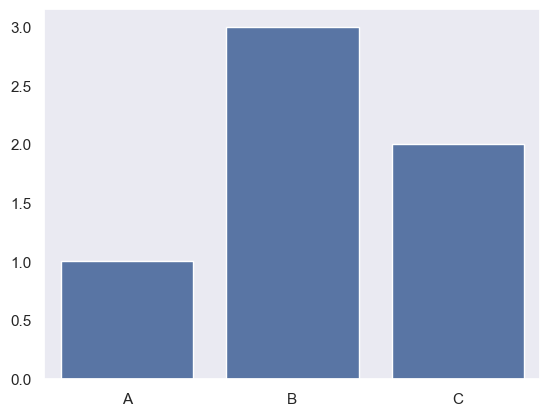

In [5]:
# Using dark background 
sns.set_theme(style='dark')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

## `axes_style` function :

This function is used to set the style of the axes of your plots. It can take a variety of inputs such as 'white', 'dark', 'ticks' or a dictionary with key-value pairs of valid style options.


<Axes: >

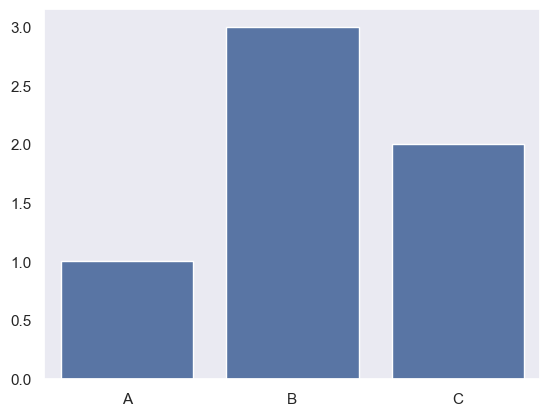

In [6]:
# Example: 
sns.axes_style(style = 'white')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

## 🔬 Deep Dive : axes_style & set_context

```python
sns.axes_style('white')               # inspect/set axes style
with sns.axes_style('whitegrid'):
    sns.scatterplot(...)              # temporary style block only

sns.set_context('poster')             # scale everything larger
sns.set_context('paper', font_scale=1.5)   # custom sized
```

- axes_style — coordinated axes look (grid, ticks, spines)
- context manager — style applies INSIDE `with` block only → scoped
- set_context: 'paper','notebook','talk','poster' — scale text/lines
- rcParams interplay: fonts, gridsize, tick sizes
- palette/font scale passing
- per-block style uniqueness — presentation vs notebook
- visual size ladder small→huge output
- Multiple axes_style: dict override
- Readable slide figures → context 'talk'/'poster'
- grid width/font relation matches labelling

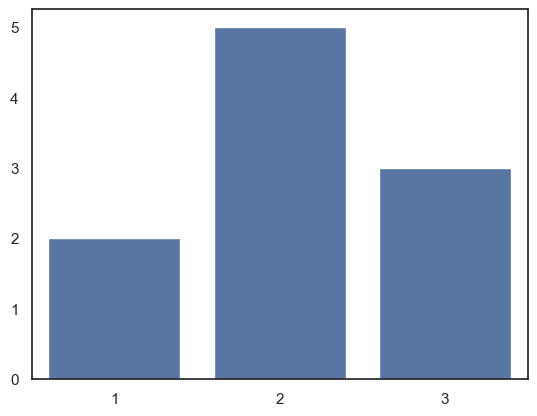

In [7]:
# Use the function as a context manager to temporarily change the style of your plots:

with sns.axes_style("white"):
    sns.barplot(x=[1, 2, 3], y=[2, 5, 3])

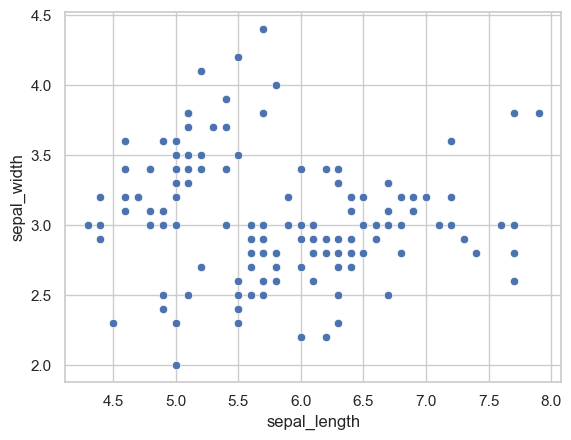

In [8]:
# Load the iris data
iris = sns.load_dataset("iris")

# Set the style of the axes to "darkgrid"
sns.set_style("whitegrid")

# Create a scatter plot of sepal length vs sepal width
sns.scatterplot(x="sepal_length", y="sepal_width", data=iris)

# Show the plot
plt.show()


## Scaling Figure Styles - `sns.set_context()`

Matplotlib allows you to generate powerful plots, but styling those plots for different presentation purposes is difficult. Seaborn makes it easy to produce the same plots in a variety of different visual formats so you can customize the presentation of your data for the appropriate context, whether it be a research paper or a conference poster.

You can set the visual format, or context, using `sns.set_context()`

Within the usage of `sns.set_context()`, there are three levels of complexity:

* Pass in one parameter that adjusts the scale of the plot
* Pass in two parameters - one for the scale and the other for the font size
* Pass in three parameters - including the previous two, as well as the rc with the style parameter that you want to override

### Scaling Plots
Seaborn has four presets which set the size of the plot and allow you to customize your figure depending on how it will be presented.

In order of relative size they are: `paper`, `notebook`, `talk`, and `poster`. The notebook style is the default.

<Axes: xlabel='day', ylabel='total_bill'>

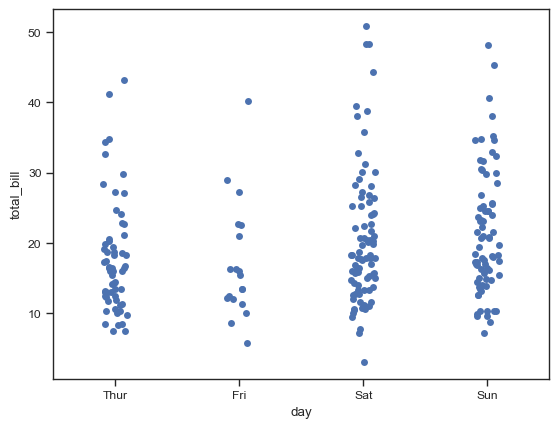

In [9]:
sns.set_style("ticks")

# Smallest context: paper
sns.set_context("paper")
sns.stripplot(x="day", y="total_bill", data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

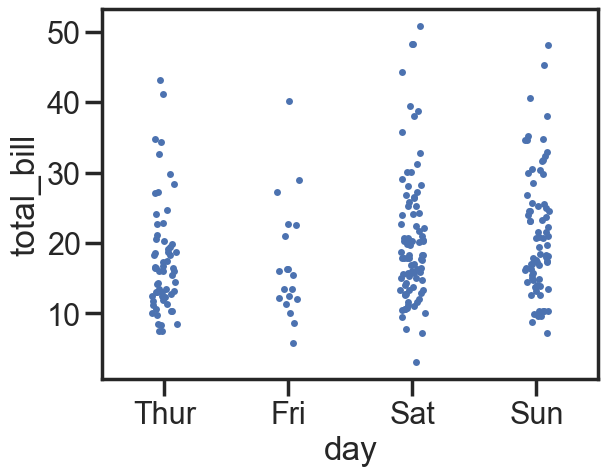

In [10]:
sns.set_style("ticks")

# Largest Context: poster
sns.set_context("poster")
sns.stripplot(x="day", y="total_bill", data=tips)

### Scaling Fonts and Line Widths

You are also able to change the size of the text using the font_scale parameter for `sns.set_context()`

You may want to also change the line width so it matches. We do this with the rc parameter, which we’ll explain in detail below.



<Axes: xlabel='day', ylabel='total_bill'>

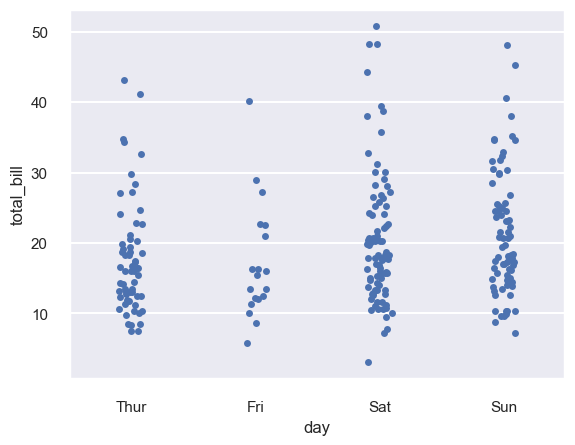

In [11]:
# Set font scale and reduce grid line width to match
sns.set_style("darkgrid")

sns.set_context("poster", font_scale = .5, rc={"grid.linewidth": 1.5})
sns.stripplot(x="day", y="total_bill", data=tips)

> While you’re able to change these parameters, you should keep in mind that it’s not always useful to make certain changes. Notice in this example that we’ve changed the line width, but because of it’s relative size to the plot, it distracts from the actual plotted data.



<Axes: xlabel='day', ylabel='total_bill'>

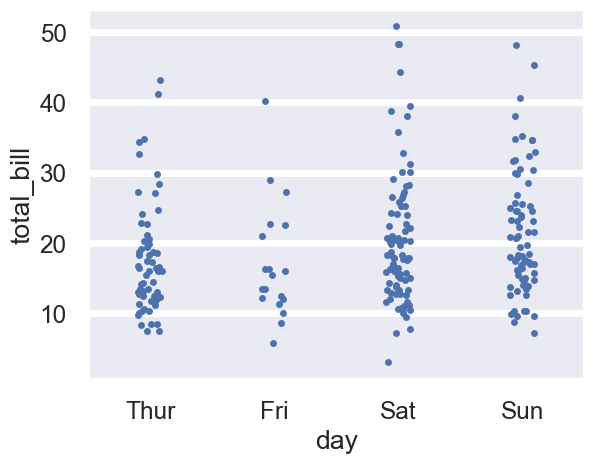

In [12]:
# Set font scale and increase grid line width to match
sns.set_context("poster", font_scale = .8, rc={"grid.linewidth": 5})
sns.stripplot(x="day", y="total_bill", data=tips)

### The RC Parameter

As we mentioned above, if you want to override any of these standards, you can use `sns.set_context` and pass in the parameter rc to target and reset the value of an individual parameter in a dictionary. `rc` stands for the phrase ‘run command’ - essentially, configurations which will execute when you run your code.

In [13]:
# Plotting context function

sns.plotting_context() 
# These are the property you can tweak in rc parameter

{'font.size': 19.200000000000003,
 'axes.labelsize': 19.200000000000003,
 'axes.titlesize': 19.200000000000003,
 'xtick.labelsize': 17.6,
 'ytick.labelsize': 17.6,
 'legend.fontsize': 17.6,
 'legend.title_fontsize': 19.200000000000003,
 'axes.linewidth': 2.5,
 'grid.linewidth': 5.0,
 'lines.linewidth': 3.0,
 'lines.markersize': 12.0,
 'patch.linewidth': 2.0,
 'xtick.major.width': 2.5,
 'ytick.major.width': 2.5,
 'xtick.minor.width': 2.0,
 'ytick.minor.width': 2.0,
 'xtick.major.size': 12.0,
 'ytick.major.size': 12.0,
 'xtick.minor.size': 8.0,
 'ytick.minor.size': 8.0}

## `seaborn.set_color_codes(palette=’deep’)`

Change how matplotlib color shorthands are interpreted.

Calling this will change how shorthand codes like “b” or “g” are interpreted by matplotlib in subsequent plots.

Parameters:	
> `palette` : `{deep, muted, pastel, dark, bright, colorblind}`
Named seaborn palette to use as the source of colors.

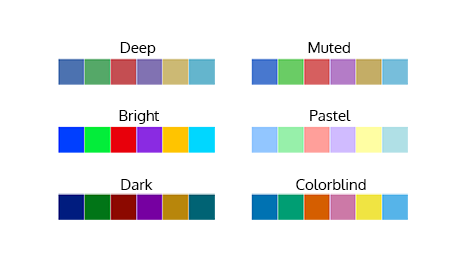


## 🔬 Deep Dive : set_color_codes & palettes

```python
sns.set_color_codes(palette='deep')    # 'b' → deep blue, 'g' → deep green
sns.set_color_codes(palette='pastel')  # same codes different palette
```

- color_codes: matplotlib letter shortcuts ('b','g','r','c','m','y','k')
- palette swap — RIDE letter → different shade
- deep/pastel — distinct family volumes
- convenient for existing matplotlib-style code
- set_palette — global color cycle for seaborn plots
- color_palette('deep', n) — generate n colors
- custom palette: hex list → color_palette([...])
- as_cmap=True — palette→heatmap colormap
- palettes: qualitative (deep/pastel/husl), sequential (viridis/magma), diverging
- ColorBrand coherent visuals

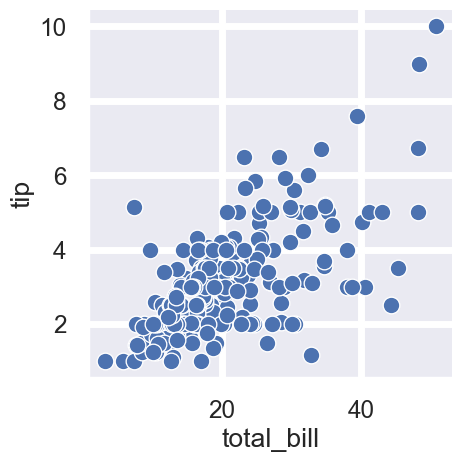

In [14]:
# 'b' color code with deep palette 
sns.set_color_codes(palette='deep')
sns.relplot(data=tips, x='total_bill', y='tip', color='b')

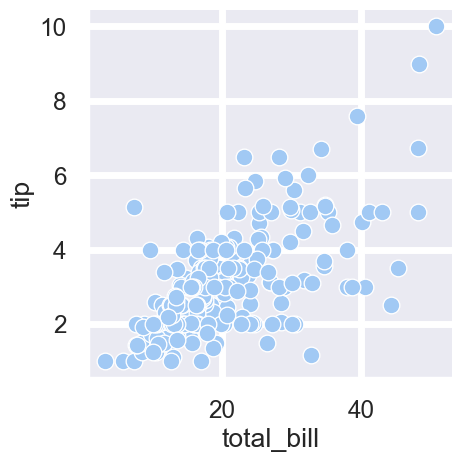

In [15]:
# 'b' color code with pastel palette 
sns.set_color_codes(palette='pastel')
sns.relplot(data=tips, x='total_bill', y='tip', color='b')

# Color palettes

* set_palette

> Set the matplotlib color cycle using a seaborn palette.

* color_palette

> Return a list of colors or continuous colormap defining a palette.

* husl_palette

> Return hues with constant lightness and saturation in the HUSL system.

* hls_palette

> Return hues with constant lightness and saturation in the HLS system.

* cubehelix_palette

> Make a sequential palette from the cubehelix system.

* dark_palette

> Make a sequential palette that blends from dark to color.

* light_palette

> Make a sequential palette that blends from light to color.

* diverging_palette

> Make a diverging palette between two HUSL colors.

* blend_palette

> Make a palette that blends between a list of colors.

* xkcd_palette

> Make a palette with color names from the xkcd color survey.

* crayon_palette

> Make a palette with color names from Crayola crayons.

* mpl_palette

> Return a palette or colormap from the matplotlib registry.

### `color_palette`

https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette

In Seaborn, the `color_palette()` function allows you to easily specify the colors for your plots. You can use pre-defined palettes, such as "deep", "muted", "pastel", "bright", "dark", and "colorblind", or you can create your own custom palette.

When using a pre-defined palette, you can specify the number of colors you want to use by passing in the desired number as the argument. 

For example, using the "deep" palette and specifying 6 colors will return an array of 6 RGB color codes that can be used in your plot.

## 🔬 Deep Dive : color_palette & cubehelix

```python
deep_colors = sns.color_palette("deep", 6)         # top 6 colors deep
colors = sns.color_palette(["#00CD00", "#00FFAA", "#FCCC00", "#FF0000"])
sns.color_palette("husl", 8, .7)                    # hue-const lightness
sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, reverse=True)
sns.set_palette("husl", n_colors=8)                 # global color cycle
```

- color_palette(name, n) — return list of n RGB tuples
- named: deep/muted/bright/pastel/dark, hls/husl, Sequential, diverging
- custom list of hex → explicit color wants
- set_palette — global default color for future plots (pythonic)
- cubehelix: perceptually uniform rainbow sequence — great heatmaps
- start/rot/gamma control shift; light/dark bounds; reverse flip
- barplot palette= same list reuse
- color choice affects categorical distinction
- sequential for ordered data value; qualitative for labels
- nice formatting: sns.color_palette("Paired") — paired groups

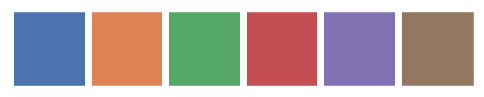

In [16]:
deep_colors = sns.color_palette("deep", 6)

# Just to show the color palette using palplot
sns.palplot(deep_colors)
plt.show()

You can also create your own custom color palette by passing in a list of RGB color codes.

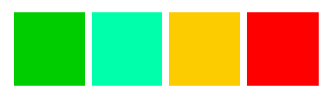

In [17]:
colors = ["#00CD00", "#00FFAA", "#FCCC00", "#FF0000"]
colors = sns.color_palette(colors)
sns.palplot(colors)
plt.show()

The `as_cmap` parameter in seaborn's `color_palette` function is a boolean flag that, when set to True, returns a colormap object instead of a list of RGB values. This can be useful when plotting data that needs to be colored based on a continuous variable, such as a heatmap or a 2D histogram. The colormap can then be passed to other plotting functions, such as heatmap or imshow, to color the plotted data. An example of using color_palette with as_cmap is:


## 🔬 Deep Dive : Color to colormap (cmap)

```python
cmap = sns.color_palette('Blues', as_cmap=True)   # palette → colormap
sns.heatmap(data, cmap=cmap)                      # use on continuous data
cmap = sns.color_palette(["#00CD00","#FF0000"], as_cmap=True)   # custom 2-color
```

- color_palette(...).as_cmap — palette of discrete colors → continuous colormap
- sequential palettes ('Blues','Greens','Reds','viridis','rocket') → heatmaps
- custom hex list → 2/3-stop colormap
- corr() → correlation matrix cell colors
- readability: choose sequential for magnitude; diverging for +/- signed
- palette param passed to plotting (heatmap cmap= overrides)
- hex_colors = sns.color_palette("husl", 8, 0.7).as_hex()
- consistent color language across graphs
- matrix heatmaps practitioners always use cmap
- as_cmap comes into play with sns heatmap directly

In [18]:
data = tips.corr()

# Create a colormap from a seaborn color palette
cmap = sns.color_palette("Blues", as_cmap=True)

# Create a heatmap using the colormap
sns.heatmap(data, cmap=cmap)
plt.show()

ValueError: could not convert string to float: 'Female'

In [ ]:
data = tips.corr()

# Create a colormap using your own custom color code
colors = ["#FFFF00", "#00FFAA", "#FCCCDD", "#FCCC00"]
cmap = sns.color_palette(colors, as_cmap=True)

# Create a heatmap using the colormap
sns.heatmap(data, cmap=cmap)
plt.show()

## `set_palette`
The `set_palette()` function in seaborn allows you to specify a color palette for your plots. This can be done by passing in one of the pre-defined seaborn palettes (such as "deep", "muted", "bright", etc.) or by passing in your own custom list of colors or color_palette.

Here is an example of using set_palette() to specify the "deep" palette:

In [ ]:
# This will set palette as deep
sns.set_palette('deep')
sns.lineplot(data=tips, x='tip', y='total_bill')
plt.show()

In [19]:
# Loading different data
import plotly.express as px

gap = px.data.gapminder()
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


You can also pass in a custom list of colors. For example, the following code would set the palette to the colors red, blue, and green:



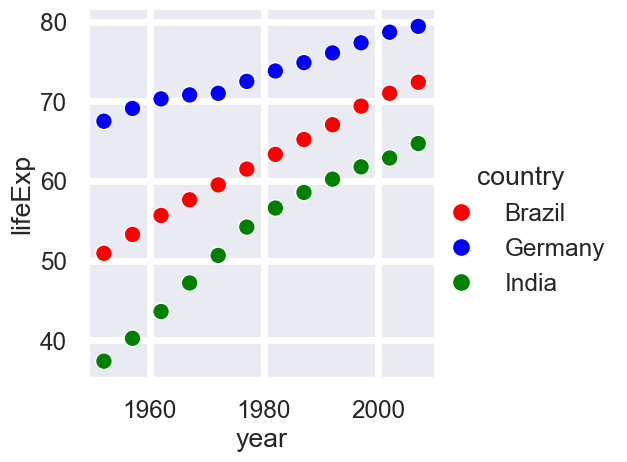

In [20]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

# Seting palette to three colors
sns.set_palette(["red", "blue", "green"])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')



You can also pass in a number of different arguments to set_palette. For example, the following code sets the color palette to a specific hue, with 8 colors, and a desaturated lightness:




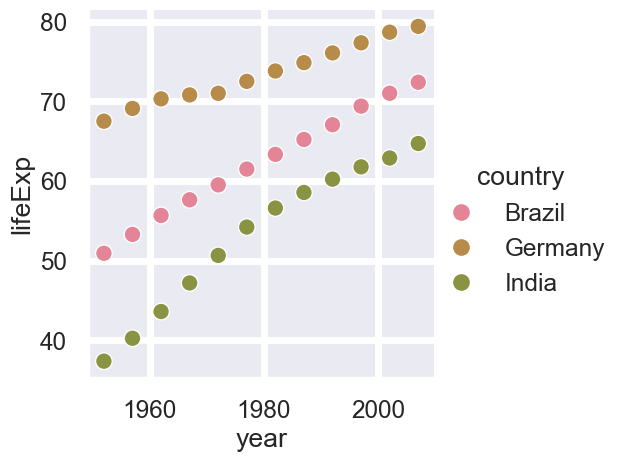

In [21]:
sns.set_palette("husl", 8, .7)
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')

Now say we have set pallete colors and passed three colors, like we did above and want to plot of 4 or more country line plots? 

What color will be assinged to 4th country? Let's see

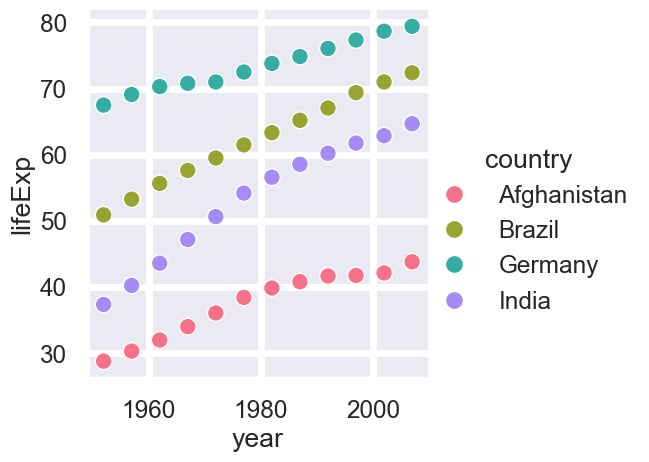

In [22]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany','Afghanistan'])]

# Seting palette to three colors
sns.set_palette(["red", "blue", "green"])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')



See it took, color palette we set as - sns.set_palette("husl",8, .7), with eight colors. Even if we are specifying set palette as `['red', 'blue', 'green']`


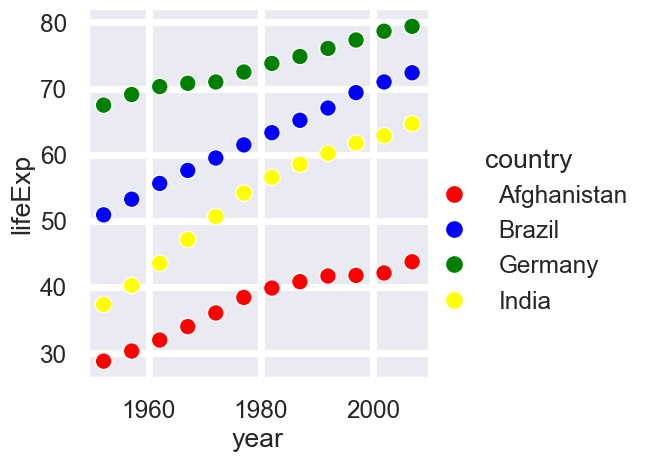

In [23]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany','Afghanistan'])]

# Seting palette to four colors 
sns.set_palette(["red", "blue", "green", 'yellow'])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')

# This will give right expected result as it has enough colors in the palette to show.

## seaborn.husl_palette

`seaborn.husl_palette(n_colors=6, h=0.01, s=0.9, l=0.65, as_cmap=False)`
> Return hues with constant lightness and saturation in the HUSL system.

> The hues are evenly sampled along a circular path. The resulting palette will be appropriate for categorical or cyclical data.

> The `h`, `l`, and `s` values should be between 0 and 1.


Parameters:
> `n_colors` : `int` Number of colors in the palette.

> `h` : `float` (0-1) The value of the first hue.

> `l` : `float` (0-1)  The lightness value.

> `s`: `float` (0-1) The saturation intensity.

> `as_cmap` : `bool` If True, return a matplotlib colormap object.


`sns.hls_palette()` > This function is similar to husl_palette(), but it uses a nonlinear color space that is more perceptually uniform, and saturation in the HLS system.

We can also use 'husl' or 'hsl' parameter in set_palette function for the same. Like we did in above example.

In [24]:
# Iris data loading
iris = sns.load_dataset('iris')

## cubehelix_palette

The seaborn.cubehelix_palette function is used to generate a colormap based on the cubehelix color scheme, which is a sequential color map with a linear increase in brightness and a smooth progression through the hues of the spectrum. 
This function takes several optional parameters such as `start`, `rot`, `gamma`, `light`, `dark`, `reverse` and `as_cmap` to control the properties of the color palette.

For example, the following code generates a cubehelix color palette with 8 colors, starting from a blue hue, and with increasing brightness and a rotation of 0.5:


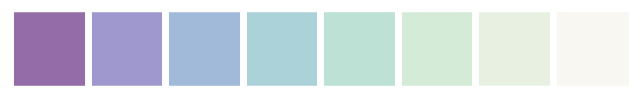

In [25]:
colors = sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, reverse=True)
sns.palplot(colors)

This palette can be used to color various plotting elements such as bars, lines, and points in a graph.


C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_26312\3066327368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='petal_length', data=iris, palette=colors)
C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_26312\3066327368.py:1: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(x='species', y='petal_length', data=iris, palette=colors)


<Axes: xlabel='species', ylabel='petal_length'>

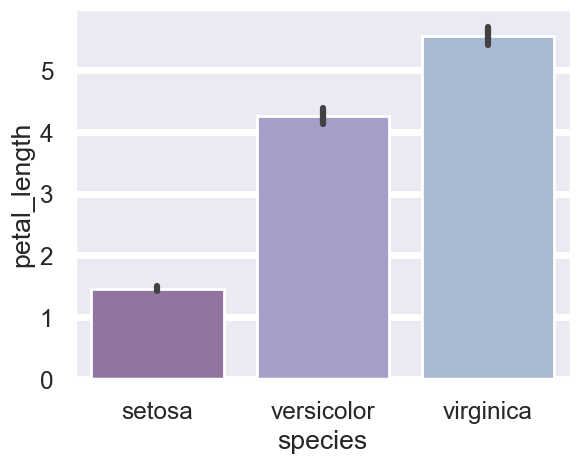

In [26]:
sns.barplot(x='species', y='petal_length', data=iris, palette=colors)

Alternatively, it can also be passed as a colormap to a heatmap or a 2D histogram.


### Functional tools
map/filter apply functions; reduce aggregates. Often paired with lambdas.

In [27]:
sns.heatmap(iris.corr(), cmap=sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, as_cmap=True))

ValueError: could not convert string to float: 'setosa'

All those function mentioned in coloring have similar implementation.https://

Follow below links to read about specif palette - 
seaborn.pydata.org/api.html#color-palettes 

## Summary

This notebook put style control at your fingertips. You saw that `sns.set_theme()` restores a consistent baseline, and that three families of settings shape every figure: **styles** (`sns.set_style` with `darkgrid`, `whitegrid`, `white`, `dark`, `ticks`) for the background, **contexts** (`sns.set_context` with `paper`, `notebook`, `talk`, `poster`) for proportional scaling of fonts and lines, and **palettes** (`sns.color_palette`, `sns.set_palette`) for coherent, accessible colour schemes across all plots in the notebook. Crucially, these settings are global and persistent — one `set_theme()` call near the top of a notebook explains why every chart downstream shares the same visual language. Pick a palette, pick a context, set it once, and your whole analysis looks like a designed product rather than a pile of defaults.